<a href="https://colab.research.google.com/github/dee1empire/-ITAI-1371-ML-Labs-/blob/main/Copy_of_mod_6_DeloresBledsoe_ITAI_1371.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error
import numpy as np

# Load and prepare the data
df = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')

# Drop rows with missing age
df.dropna(subset=['Age'], inplace=True)

# Define features and target
features = ['Age', 'Pclass']
target_reg = 'Fare'

X_reg = df[features]
y_reg = df[target_reg]

# Split the data
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


**TRAIN & EVALUATE LINEAR REGRESSION**

In [ ]:
from sklearn.linear_model import LinearRegression

# Create the model instance
lr_model = LinearRegression()

# Train the model
lr_model.fit(X_train_reg, y_train_reg)

# Make predictions
y_pred_reg = lr_model.predict(X_test_reg)

# Evaluate the model
mse = mean_squared_error(y_test_reg, y_pred_reg)
rmse = np.sqrt(mse)

print(f'Mean Squared Error for Fare Prediction: {mse:.2f}')
print(f'Root Mean Squared Error (RMSE): {rmse:.2f}')
print('Model Coefficients:', lr_model.coef_)
print('Intercept:', lr_model.intercept_)

Mean Squared Error for Fare Prediction: 3364.92
Root Mean Squared Error (RMSE): 58.01
Model Coefficients: [ -0.43695889 -38.29728935]
Intercept: 133.30726668128784


-Observation (Regression)
The RMSE is about $58,  meaning the model's fare predictions are off by ~ $58 on average.
- The MSE (mean squared error) has a value of 3364.92 which is showing the average of the squared differences between the actual fares and the predicted fares. Because it squares the errors, it heavily penalizes larger mistakes. It is in "squared dollars," which is why we take the square root (RMSE) to get back to a readable dollar amount($58).


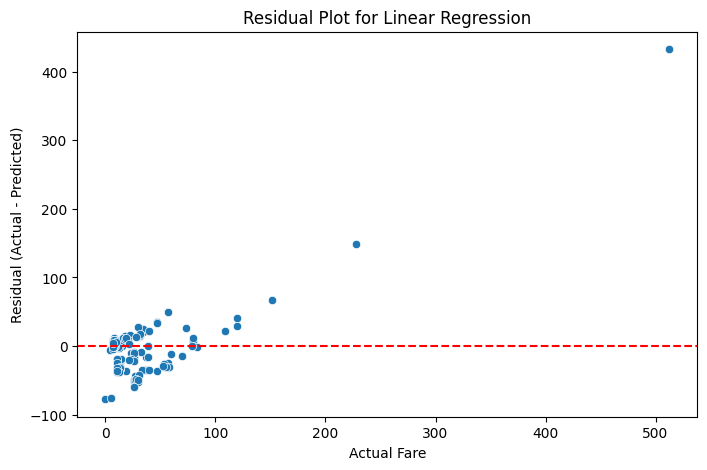

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_test_reg, y=y_test_reg - y_pred_reg)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Actual Fare')
plt.ylabel('Residual (Actual - Predicted)')
plt.title('Residual Plot for Linear Regression')
plt.show()

Residuals are somewhat widely spread, confirming the model is simple and underfits. This is expected beause I only used Age and Pclass.

**FEATURE IMPACT VISUALIZATION (FITS AFTER COEFFICIENTS)**

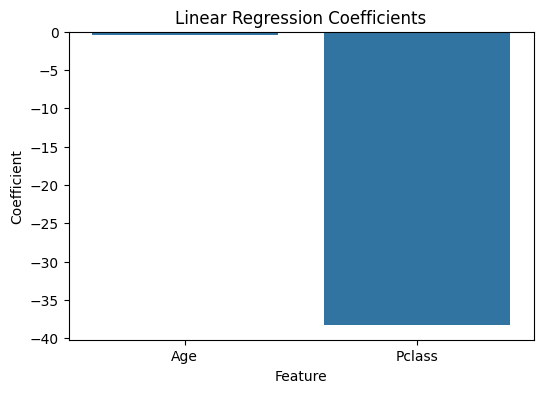

In [ ]:
coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': lr_model.coef_
    })

plt.figure(figsize=(6, 4))
sns.barplot(data=coef_df, x='Feature', y='Coefficient')
plt.title('Linear Regression Coefficients')
plt.show()



*   Pclass has a strong negative impact on fare.
*   Age has a small positive impact.
This aligns with Titanic pricing: higher classespaid more.



**PREPARE MODEL**

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

# Encode Sex column
df['Sex'].map({'male': 0, 'female': 1})

# Define features and target
features_cls = ['Age', 'Pclass', 'Sex']
target_cls = 'Survived'

X_cls = df[features_cls]
y_cls = df[target_cls]

# Split the data
X_trian_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42
    )

**TRAIN & EVALUATE LOGISTICS REGRESSION**

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

X_train_cls = pd.get_dummies(X_trian_cls, drop_first=True)
X_test_cls = pd.get_dummies(X_test_cls, drop_first=True)

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_cls, y_train_cls)

y_pred_cls = log_model.predict(X_test_cls)

accuracy = accuracy_score(y_test_cls, y_pred_cls)
print(f'Accuracy for Survival Prediction: {accuracy:.2%}')

Accuracy for Survival Prediction: 74.83%


**CONFUSION MATRIX**

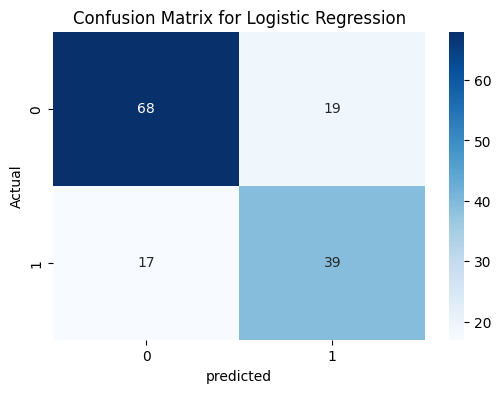

In [ ]:
cm = confusion_matrix(y_test_cls, y_pred_cls)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Logistic Regression')
plt.show()



*  Model correctly identifies many survivors and non-survivors.
*  Some false negatives remain(predicting "did not survive" when they did).



**LOGISTIC REGRESSION COEFFICIENTS**

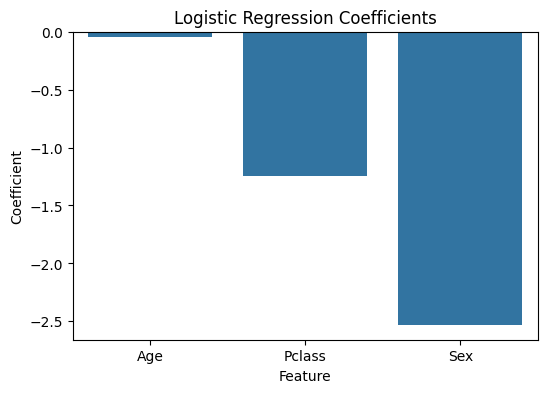

In [ ]:
coef_df_cls = pd.DataFrame({
    'Feature': features_cls,
    'Coefficient': log_model.coef_[0]
})

plt.figure(figsize=(6, 4))
sns.barplot(data=coef_df_cls, x='Feature', y='Coefficient')
plt.title('Logistic Regression Coefficients')
plt.show()



*   Sex has the strongest positive coefficient and being female increases survival probability.
*   Pclass strongly decreases survival probability .
*  Age has a small negative effect (younger passengers survived more).



           **KNOWLEDGE CHECK**


 1. In your words, what is the key difference between a regression problem and a classification problem?
 ***There is a key difference between a regression problem and a classification problem. Regression problems predicts a continuous numerical value, while a classification problem predicts a discrete category or class label.Therefore a regression problem is answerinng "how much" while a classification problem is answering "which class".


 2. The `LinearRegression` model has an attribute called `.coef_`. After you train the model, print `lr_model.coef_`. What do these numbers represent?
 ***They are the slopes learned by the model. Each coefficient shows how much the predicted fare changes when that feature increases by 1 unit, holding all other features constant. Therefore, the number of people stay the same while the fare changes.


 3. Why did we use `mean_squared_error` to evaluate the regression model but `accuracy_score` for the classification model? Why wouldn't accuracy be a good metric for the fare prediction task?
 ***MSE (mean_squared_error) measures how far off numerical predictions are, which is great for continuous outputs.
 Accuracy measures how many class labels were predicted correctly, which works well for classification.
 Accuracy would not work well for fare prediction because a fare is continuous. A prediction of $2 vs $3 is considered wrong under accuracy no matter how close the difference. Regression needs a metric that measures how big the error is, not just wether it is correct.       